<a href="https://colab.research.google.com/github/himadri-lukhi/OIBSIP_DataAnalytics_Level1_Project4/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sentiment Analysis

Objective

To preprocess and analyze user review text, extract meaningful features using TF-IDF vectorization, and build a Multinomial Naive Bayes model for accurate sentiment classification and insight generation.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For machine learning and NLP:

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Data loading

In [5]:
from google.colab import files

uploaded = files.upload()

Saving user_reviews.csv to user_reviews.csv


In [36]:
df = pd.read_csv('user_reviews.csv')

In [37]:
df

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
...,...,...,...,...,...
64290,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64291,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64292,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64293,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


Handling Missing Values

In [39]:
df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [40]:
df.shape

(64295, 5)

In [41]:
df = df.dropna(subset=['Translated_Review', 'Sentiment']).copy()

In [42]:
df['Sentiment'].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

In [43]:
df.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [44]:
print("Dataset shape after removing null values:", df.shape)

Dataset shape after removing null values: (37427, 5)


In [45]:
df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


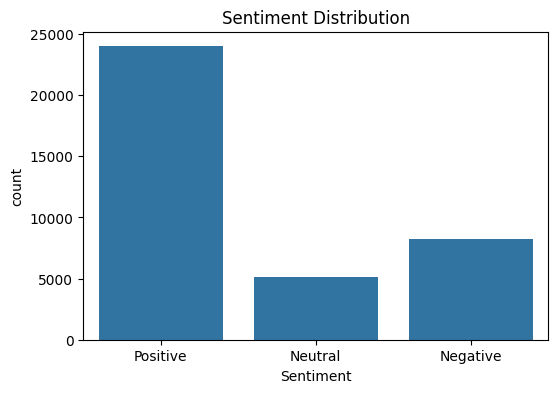

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

In [47]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5158


In [48]:
df['Sentiment'] = df['Sentiment'].str.strip()

Encode Sentiment labels

In [49]:
df['Sentiment'] = df['Sentiment'].map({
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
})

In [50]:
print(df['Sentiment'].head())
print(df['Sentiment'].unique())

0    1
1    1
3    1
4    1
5    1
Name: Sentiment, dtype: int64
[ 1  0 -1]


Text preprocessing

In [51]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [53]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    words = [stemmer.stem(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [54]:
import re
df['Cleaned_Review'] = df['Translated_Review'].apply(clean_text)

In [56]:
df[['Translated_Review', 'Cleaned_Review']].head()

,Translated_Review,Cleaned_Review
0,I like eat delicious food. That's I'm cooking ...,like eat delici food that im cook food case be...
1,This help eating healthy exercise regular basis,help eat healthi exercis regular basi
3,Works great especially going grocery store,work great especi go groceri store
4,Best idea us,best idea us
5,Best way,best way


Feature Extraction using TF-IDF

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Review']).toarray()

y = df['Sentiment']

In [58]:
print(X.shape)
print(y.shape)

(37427, 5000)
(37427,)


In [59]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
print(X_train.shape)
print(X_test.shape)

(29941, 5000)
(7486, 5000)


Train Naive Bayes Model

In [61]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [62]:
y_pred = model.predict(X_test)

Confusion Matrix Visualization

In [63]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7323002938819129


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.90      0.40      0.55      1653
           0       0.88      0.09      0.17      1049
           1       0.71      0.99      0.83      4784

    accuracy                           0.73      7486
   macro avg       0.83      0.49      0.52      7486
weighted avg       0.78      0.73      0.67      7486



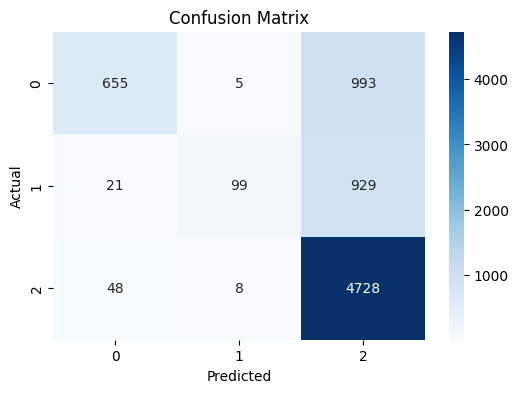

In [65]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 Word Cloud to identify frequently occurring words

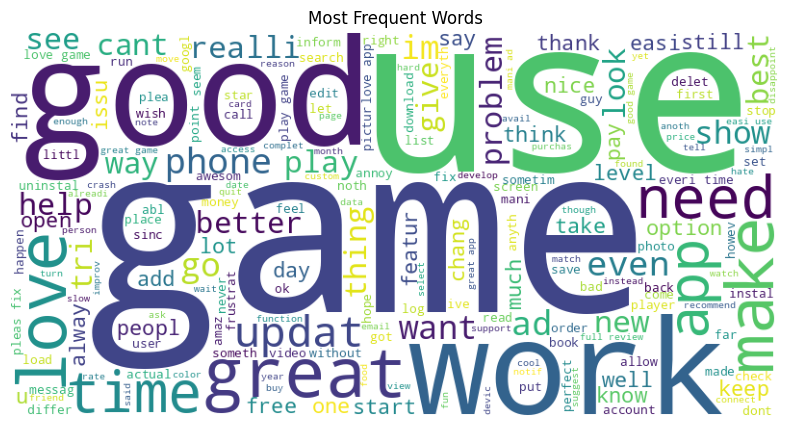

In [67]:
from wordcloud import WordCloud

text = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

#Key Insights

• Reviews were successfully classified into Positive, Negative, and Neutral sentiments.

• Positive reviews indicate overall user satisfaction with app features and performance.

• Negative reviews highlight common issues such as bugs, crashes, and usability concerns.

• The sentiment analysis model achieved approximately 73% accuracy.

#Recommendations

• Regularly monitor user reviews to understand customer sentiment.

• Address recurring issues identified in negative reviews.

• Consider user suggestions from neutral reviews for future improvements.

• Implement sentiment analysis to support data-driven decision-making and app
enhancement.